In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_csv('../data/superstore.csv', encoding='latin1')

# Inspect
print(df.shape)        # Should show ~9994 rows
print(df.dtypes)
print(df.isnull().sum())

# Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract month/year for trend analysis
df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Year'] = df['Order Date'].dt.year

# Check for duplicates
print(f"Duplicates: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Confirm no nulls in key columns
print(df[['Sales', 'Profit', 'Category', 'Region']].isnull().sum())

(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicates: 0
Sales       0
Profit    

In [2]:
import sqlite3
import pandas as pd

# --- Fix data before SQL ---
df = df.copy()

# Convert unsupported types
df['Order Date'] = df['Order Date'].astype(str)
df['Ship Date'] = df['Ship Date'].astype(str)
df['Order Month'] = df['Order Month'].astype(str)

# --- Load dataframe into SQLite ---
conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')

# --- Query 1: Monthly revenue trend ---
monthly = pd.read_sql_query("""
    SELECT strftime('%Y-%m', "Order Date") AS month,
           ROUND(SUM(Sales), 2) AS total_revenue,
           ROUND(SUM(Profit), 2) AS total_profit
    FROM sales
    GROUP BY month
    ORDER BY month
""", conn)

# --- Query 2: Top categories + sub-categories ---
category = pd.read_sql_query("""
    SELECT Category, "Sub-Category",
           ROUND(SUM(Sales), 2) AS revenue
    FROM sales
    GROUP BY Category, "Sub-Category"
    ORDER BY revenue DESC
    LIMIT 10
""", conn)

# --- Query 3: Regional performance ---
region = pd.read_sql_query("""
    SELECT Region,
           ROUND(SUM(Sales), 2) AS revenue,
           ROUND(AVG(Profit), 2) AS avg_profit
    FROM sales
    GROUP BY Region
    ORDER BY revenue DESC
""", conn)

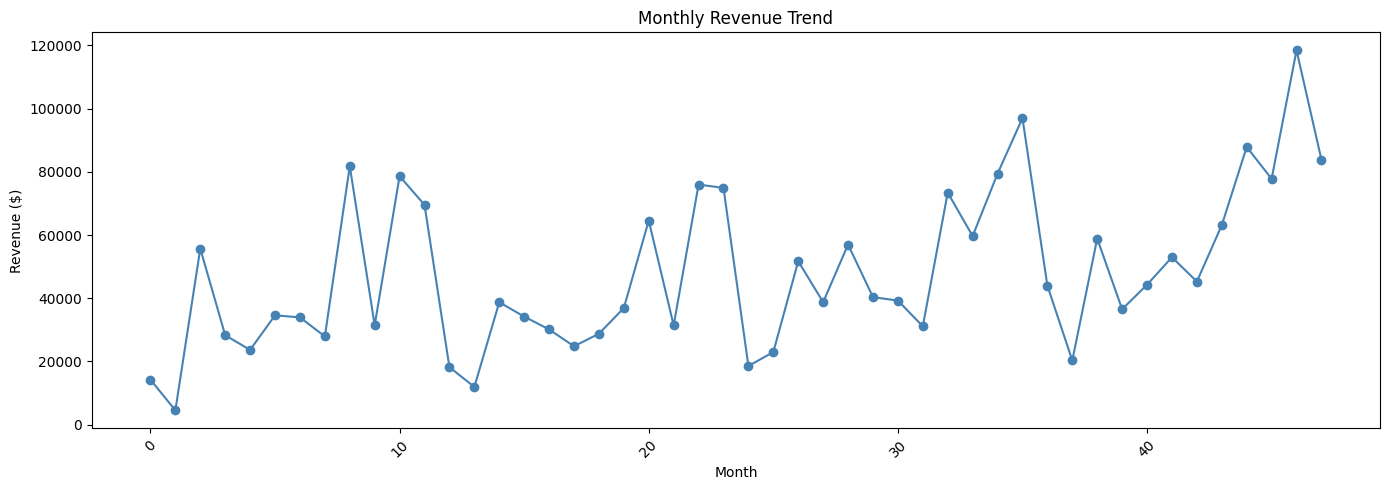

In [3]:
plt.figure(figsize=(14,5))
monthly['total_revenue'].plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/monthly_revenue_trend.png')
plt.show()

C:\Users\varsh\AppData\Local\Temp\ipykernel_32052\3676005422.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category.head(10), x='revenue', y='Sub-Category', palette='Blues_d')


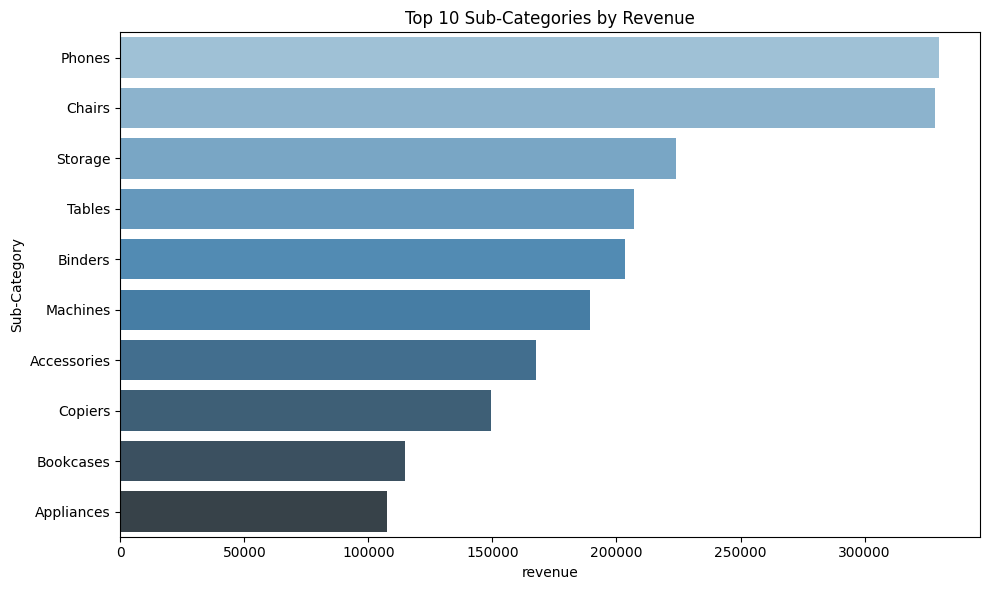

In [4]:
plt.figure(figsize=(10,6))
sns.barplot(data=category.head(10), x='revenue', y='Sub-Category', palette='Blues_d')
plt.title('Top 10 Sub-Categories by Revenue')
plt.tight_layout()
plt.savefig('../outputs/top_subcategories.png')
plt.show()

C:\Users\varsh\AppData\Local\Temp\ipykernel_32052\829285785.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region, x='Region', y='revenue', palette='Set2')


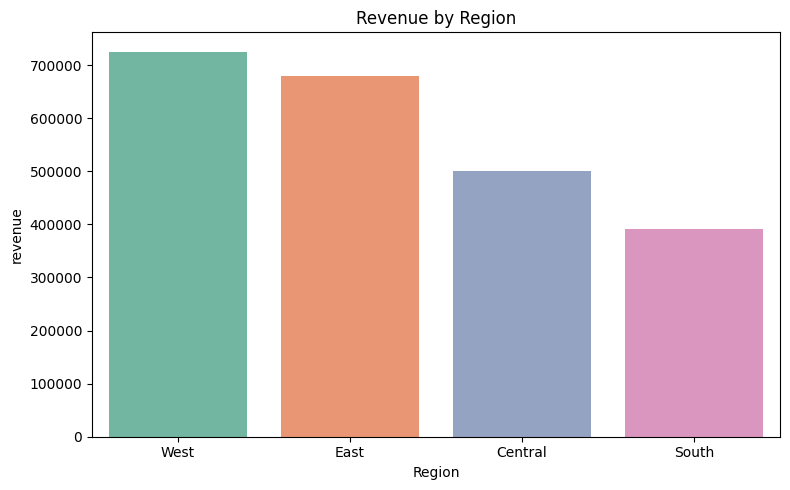

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(data=region, x='Region', y='revenue', palette='Set2')
plt.title('Revenue by Region')
plt.tight_layout()
plt.savefig('../outputs/regional_revenue.png')
plt.show()

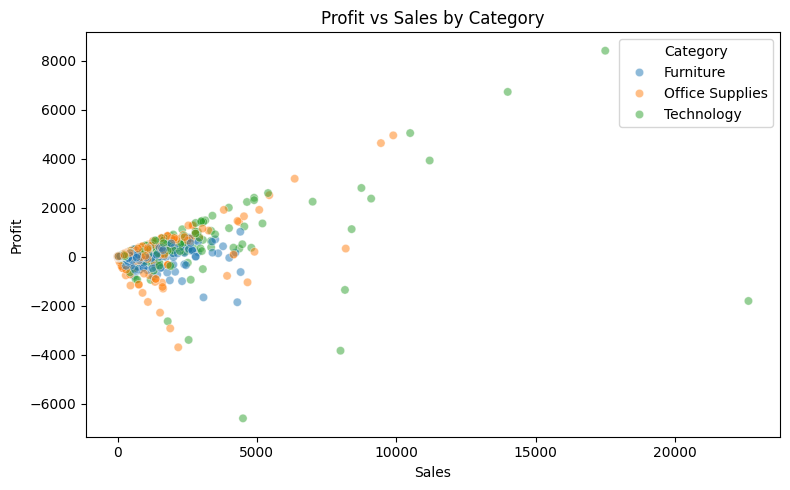

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.5)
plt.title('Profit vs Sales by Category')
plt.tight_layout()
plt.savefig('../outputs/profit_vs_sales.png')
plt.show()

C:\Users\varsh\AppData\Local\Temp\ipykernel_32052\1597683650.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yoy, x='Order Year', y='Sales', palette='coolwarm')


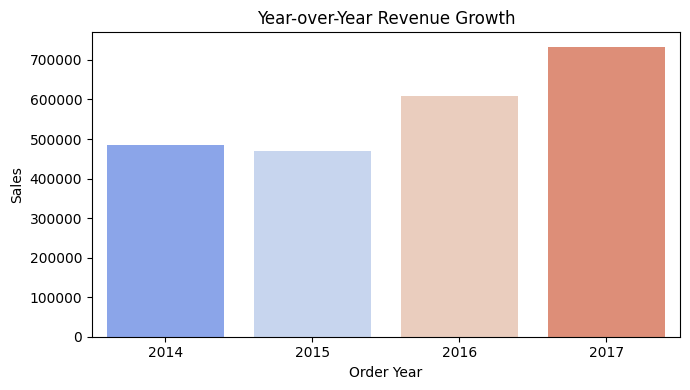

In [7]:
yoy = df.groupby('Order Year')['Sales'].sum().reset_index()
plt.figure(figsize=(7,4))
sns.barplot(data=yoy, x='Order Year', y='Sales', palette='coolwarm')
plt.title('Year-over-Year Revenue Growth')
plt.tight_layout()
plt.savefig('../outputs/yoy_growth.png')
plt.show()

Insight 1: Revenue peaks in Q4 (Oct–Dec), suggesting strong seasonal demand.
Insight 2: Technology sub-category (Phones, Machines) drives the highest revenue.
Insight 3: West region outperforms others in total revenue; Central has lowest profit margin.
Insight 4: High-sales items in Furniture often generate negative profit — a margin risk.
Insight 5: YoY revenue grew consistently from 2014 to 2017.